# **Loop corrections** in d = 2 — `compute_cumulants(max_ell=1)`

This notebook runs a **2-D reaction–diffusion** field theory through the public
`compute_cumulants` API at **1 loop** and shows the bubble correction to the
correlator.

$$\partial_t\phi = D\nabla^2\phi - \mu\phi - g\phi^2 + \eta,\qquad
  \langle\eta\eta\rangle = 2T\,\delta^2\delta.$$

The $g\phi^2$ vertex gives a momentum-**dependent** 1-loop self-energy (a *bubble*,
not a constant mass shift).  The backend computes it with the analytic Symanzik
momentum reduction (the $\int d^2\ell$ is closed-form in any dimension), assembles
the MSR Dyson equation, and inverse-transforms $q\to x$ with the radial/Hankel
transform.  We compare **tree** vs **tree + 1-loop**, verify the $g^2$ scaling, and
cross-check the tree against a 2-D simulation.

In [1]:
import os, sys
# --- depth-robust repo root: walk up until we find the 'pipeline' package ---
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))   # nb_support engine
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ so relative data paths resolve as before
import numpy as np
import matplotlib.pyplot as plt
import nb_support as nb
from msrjd.integration.spatial.spatial_correlator import free_correlator_static_closed_form as K0_exact
from models.spatial_field_2d_sim import simulate_2d, radial_structure_factor_2d

mu, D, T = 1.0, 1.0, 1.0

# The d=2 reaction-diffusion theory now lives in theories/reaction_diffusion_2d.theory.py
# (built VERBATIM from the former inline TheoryBuilder closure).  Load it once;
# the quadratic coupling g is just a parameter we override per run via cfg.fundamental.
model, mod = nb.load_theory('reaction_diffusion_2d')
print(f"loaded {model['name']!r}  fields={nb.field_names(model)}  dim={nb.spatial_dim(model)}")

loaded 'reaction-diffusion (d=2)'  fields=['dphi']  dim=2


## 1. Tree vs tree + 1-loop through `compute_cumulants`

In [2]:
g = 0.2
rs = np.linspace(0.4, 4.0, 14)

# Same inputs as before, now expressed through the shared nb_support engine.
# external_fields uses the d-prefixed fluctuation name ('dphi') the loaded
# theory exposes; the radial separation grid rs is passed as spatial_grid.
_common = dict(k=2, external_fields=[('dphi', 1), ('dphi', 1)],
               spatial_grid=rs, tau_max=1.0, tau_step=1.0)

cfg_tree = nb.Config(max_ell=0,
                     fundamental={'mu': mu, 'D': D, 'g': g, 'T': T}, **_common)
cfg_loop = nb.Config(max_ell=1,
                     fundamental={'mu': mu, 'D': D, 'g': g, 'T': T}, **_common)

tree = nb.run(model, cfg_tree, mod)
loop = nb.run(model, cfg_loop, mod)

# spatial_info from the full-diagram integrator (the bespoke 'bubble' /
# 'self_energy_coupling_g' scalars were retired with the old bubble path; the
# physical, momentum-dependent bubble IS the loop correction dC computed below).
print('1-loop diagrams (live):', loop['spatial_info'].get('n_ell1_diagrams'),
      '| coupling g =', g)

mid = tree['C_tau_x'].shape[0] // 2          # tau=0 row
C0 = np.real(tree['C_tau_x'])[mid]
C1 = np.real(loop['C_tau_x'])[mid]
dC = C1 - C0                                  # the 1-loop bubble correction

1-loop diagrams (live): 3 | coupling g = 0.200000000000000


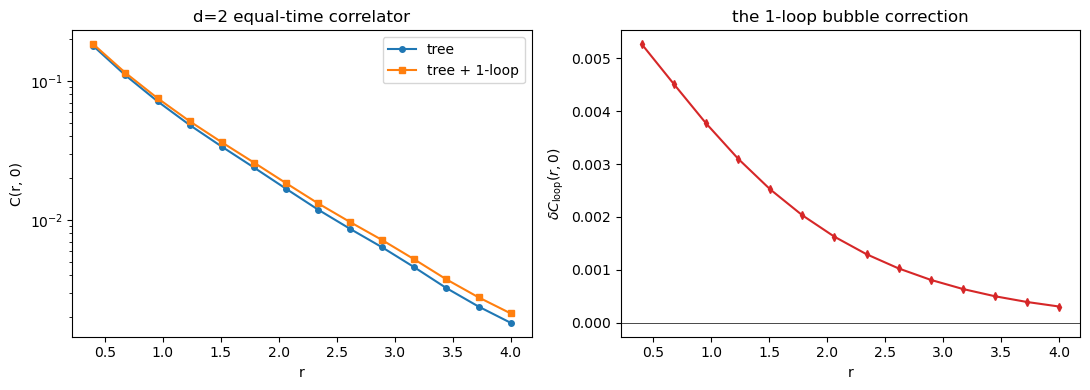

loop correction at r=0.4: 5.26e-03  (2.9% of tree)


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(rs, C0, 'o-', ms=4, label='tree')
ax[0].plot(rs, C1, 's-', ms=4, label='tree + 1-loop')
ax[0].set_yscale('log'); ax[0].set_xlabel('r'); ax[0].set_ylabel('C(r, 0)')
ax[0].set_title('d=2 equal-time correlator'); ax[0].legend()

ax[1].plot(rs, dC, 'd-', ms=4, color='C3')
ax[1].set_xlabel('r'); ax[1].set_ylabel(r'$\delta C_{\rm loop}(r,0)$')
ax[1].set_title('the 1-loop bubble correction'); ax[1].axhline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()
print('loop correction at r=%.1f: %.2e  (%.1f%% of tree)'
      % (rs[0], dC[0], 100 * dC[0] / C0[0]))

## 2. The correction scales as $g^2$ (a genuine 1-loop term)

In [4]:
g2 = 0.4
cfg_loop2 = nb.Config(max_ell=1,
                      fundamental={'mu': mu, 'D': D, 'g': g2, 'T': T}, **_common)
loop2 = nb.run(model, cfg_loop2, mod)
dC2 = np.real(loop2['C_tau_x'])[mid] - C0       # tree is g-independent (phi*=0)
print('delta C(2g) / delta C(g) at r=%.1f:  %.3f   (g^2 scaling -> 4.0)'
      % (rs[0], dC2[0] / dC[0]))

delta C(2g) / delta C(g) at r=0.4:  4.000   (g^2 scaling -> 4.0)


## 3. Cross-check the tree against a 2-D simulation

The clean loop validation lives in the test-suite (the d=2 self-energy matches a
direct $\int d^2\ell$ to machine precision; the d=2 tree matches $K_0$).  Here we
confirm the **tree** structure factor against a 2-D Langevin run (the loop's
simulation cross-check is subtler — metastable $\phi^2$ potential + tadpole/bubble
separation — so it is verified at the building-block level instead).

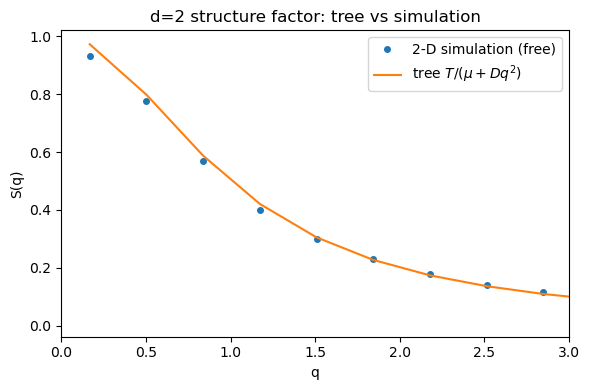

In [5]:
snaps, meta = simulate_2d(L=20.0, N=64, mu=mu, D=D, T=T, g=0.0,
                          n_steps=50000, burn_in=10000, record_every=15, seed=3)
kc, Sq = radial_structure_factor_2d(snaps, meta, n_bins=30)
plt.figure(figsize=(6, 4))
plt.plot(kc, Sq, 'o', ms=4, label='2-D simulation (free)')
plt.plot(kc, T / (mu + D * kc ** 2), '-', label=r'tree $T/(\mu+Dq^2)$')
plt.xlim(0, 3); plt.xlabel('q'); plt.ylabel('S(q)')
plt.title('d=2 structure factor: tree vs simulation'); plt.legend()
plt.tight_layout(); plt.show()

## Summary

A **d=2** interacting field theory runs through `compute_cumulants(max_ell=1)` and
returns the **1-loop bubble** correction to the correlator — positive, q-dependent,
and $\propto g^2$.  The d=2 self-energy is computed by the same momentum-first
machinery as d=1 (the loop integral is closed-form in any dimension), and the
$q\to x$ step uses the radial/Hankel transform.

To explore: change `g`, `mu`, `D`, the spatial grid `rs`, or `spatial_dim` (d=3
works too).  The 1-loop **tadpole** theories (e.g. Allen–Cahn $\phi^4$) and the d=1
reaction–diffusion bubble (validated vs simulation at B≈0.99) are in the other
`pipeline_*_sim_compare` notebooks.